In [1]:
import pandas as pd
import nfl_data_py as nfl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
list(nfl.import_pbp_data([2024], downcast=True).columns)

2024 done.
Downcasting floats.


['play_id',
 'game_id',
 'old_game_id_x',
 'home_team',
 'away_team',
 'season_type',
 'week',
 'posteam',
 'posteam_type',
 'defteam',
 'side_of_field',
 'yardline_100',
 'game_date',
 'quarter_seconds_remaining',
 'half_seconds_remaining',
 'game_seconds_remaining',
 'game_half',
 'quarter_end',
 'drive',
 'sp',
 'qtr',
 'down',
 'goal_to_go',
 'time',
 'yrdln',
 'ydstogo',
 'ydsnet',
 'desc',
 'play_type',
 'yards_gained',
 'shotgun',
 'no_huddle',
 'qb_dropback',
 'qb_kneel',
 'qb_spike',
 'qb_scramble',
 'pass_length',
 'pass_location',
 'air_yards',
 'yards_after_catch',
 'run_location',
 'run_gap',
 'field_goal_result',
 'kick_distance',
 'extra_point_result',
 'two_point_conv_result',
 'home_timeouts_remaining',
 'away_timeouts_remaining',
 'timeout',
 'timeout_team',
 'td_team',
 'td_player_name',
 'td_player_id',
 'posteam_timeouts_remaining',
 'defteam_timeouts_remaining',
 'total_home_score',
 'total_away_score',
 'posteam_score',
 'defteam_score',
 'score_differential',
 '

In [ ]:
# Select only the relevant columns
columns = ['rusher_player_name', 'posteam', 'defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards', 
           'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
           'passing_yards', 'cpoe', 'roof', 'surface']

# Loading in the NFL pbp data
data = nfl.import_pbp_data(range(2010,2025), downcast=True)
data = data[columns]

# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
data = data[columns]

# Drop all rows that are not a pass
data = data[data['play_type'] == 'pass']

# Drop the play type column
passer_data = data.drop(columns=['play_type'])

2010 done.
2011 done.
2012 done.
2013 done.
2014 done.
2015 done.
2016 done.
2017 done.
2018 done.
2019 done.
2020 done.
2021 done.
2022 done.
2023 done.
2024 done.
Downcasting floats.


In [34]:
# Group the data together by passer, week, season and aggregate
passer_df = passer_data.groupby(['passer_player_name', 'week', 'season'], as_index=False).agg(
    {'posteam' : 'first',
     'defteam' : 'first',
     'home_team' : 'first',
     'away_team' : 'first',
     'air_yards' : 'sum',
     'yards_after_catch' : 'sum',
     'epa' : 'sum',
     'complete_pass' : 'sum',
     'incomplete_pass' : 'sum',
     'interception' : 'sum',
     'qb_hit' : 'sum',
     'sack' : 'sum',
     'pass_touchdown' : 'sum',
     'passing_yards' : 'sum',
     'cpoe' : 'mean',
     'roof' : 'first',
     'surface' : 'first'
     }
)

# Create a new column that is completion percentage
passer_df['completion_percentage'] = passer_df['complete_pass'] / (passer_df['complete_pass'] + passer_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
passer_df['pass_attempts'] = passer_df['complete_pass'] + passer_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
passer_df = passer_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the passer is the home team and 0 if the passer is the away team
passer_df['home_flag'] = passer_df['home_team'] == passer_df['posteam']

# Drop the home_team and away_team columns
passer_df = passer_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
passer_df = passer_df[['passer_player_name', 'posteam', 'defteam', 'season', 'week', 'passing_yards', 'home_flag', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                        'cpoe', 'roof', 'surface']]

In [35]:
# Calculate the exponentially weighted moving average for each feature
passer_df['completion_percentage_ewma'] = passer_df.groupby('passer_player_name')['completion_percentage']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['pass_attempts_ewma'] = passer_df.groupby('passer_player_name')['pass_attempts']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['air_yards_ewma'] = passer_df.groupby('passer_player_name')['air_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['yards_after_catch_ewma'] = passer_df.groupby('passer_player_name')['yards_after_catch']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['epa_ewma'] = passer_df.groupby('passer_player_name')['epa']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['interception_ewma'] = passer_df.groupby('passer_player_name')['interception']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['qb_hit_ewma'] = passer_df.groupby('passer_player_name')['qb_hit']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['sack_ewma'] = passer_df.groupby('passer_player_name')['sack']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['pass_touchdown_ewma'] = passer_df.groupby('passer_player_name')['pass_touchdown']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['passing_yards_ewma'] = passer_df.groupby('passer_player_name')['passing_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

passer_df['cpoe_ewma'] = passer_df.groupby('passer_player_name')['cpoe']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

# Drop the non-ewma columns
passer_df = passer_df.drop(columns=['completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 
                                    'interception', 'qb_hit', 'sack', 'pass_touchdown', 'cpoe'])

In [36]:
# Select only the relevant columns
defense_columns = ['defteam', 'season', 'week', 'home_team', 'away_team', 'play_type', 'air_yards',
                   'yards_after_catch', 'epa', 'complete_pass', 'incomplete_pass', 'interception', 'qb_hit', 'sack', 'pass_touchdown',
                   'passing_yards', 'cpoe', 'roof', 'surface']


# nfl-data-py still loads other columns, so we again need to set our data equal to only the columns we want
defense_data = data[defense_columns]

# Drop the play type column
defense_data = defense_data.drop(columns=['play_type'])

# Group the data together by passer, week, season and aggregate
defense_df = defense_data.groupby(['defteam', 'week', 'season'], as_index=False).agg(
    {'home_team': 'first',
     'away_team': 'first',
     'air_yards': 'sum',
     'yards_after_catch': 'sum',
     'epa': 'sum',
     'complete_pass': 'sum',
     'incomplete_pass': 'sum',
     'interception': 'sum',
     'qb_hit': 'sum',
     'sack': 'sum',
     'pass_touchdown': 'sum',
     'passing_yards': 'sum',
     'cpoe': 'mean',
     'roof': 'first',
     'surface': 'first'
     }
)

# Create a new column that is completion percentage
defense_df['completion_percentage'] = defense_df['complete_pass'] / (defense_df['complete_pass'] + defense_df['incomplete_pass'])

# Create a new column that is the number of pass attempts
defense_df['pass_attempts'] = defense_df['complete_pass'] + defense_df['incomplete_pass']

# Drop the complete_pass and incomplete_pass columns
defense_df = defense_df.drop(columns=['complete_pass', 'incomplete_pass'])

# Create a new column that equals 1 if the defense is the home team and 0 if the defense is the away team
defense_df['home_flag'] = defense_df['home_team'] == defense_df['defteam']

# Drop the home_team and away_team columns
defense_df = defense_df.drop(columns=['home_team', 'away_team'])

# Reorder the columns
defense_df = defense_df[['defteam', 'season', 'week', 'home_flag', 'passing_yards', 'completion_percentage', 'pass_attempts',
                       'air_yards',  'yards_after_catch', 'epa', 'interception', 'qb_hit', 'sack', 'pass_touchdown', 
                       'cpoe', 'roof', 'surface']]

In [37]:
# Calculate the exponentially weighted moving average for each feature
defense_df['completion_percentage_ewma'] = defense_df.groupby('defteam')['completion_percentage']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['pass_attempts_ewma'] = defense_df.groupby('defteam')['pass_attempts']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['air_yards_ewma'] = defense_df.groupby('defteam')['air_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['yards_after_catch_ewma'] = defense_df.groupby('defteam')['yards_after_catch']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['epa_ewma'] = defense_df.groupby('defteam')['epa']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['interception_ewma'] = defense_df.groupby('defteam')['interception']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['qb_hit_ewma'] = defense_df.groupby('defteam')['qb_hit']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['sack_ewma'] = defense_df.groupby('defteam')['sack']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['pass_touchdown_ewma'] = defense_df.groupby('defteam')['pass_touchdown']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['passing_yards_ewma'] = defense_df.groupby('defteam')['passing_yards']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

defense_df['cpoe_ewma'] = defense_df.groupby('defteam')['cpoe']\
    .transform(lambda x: x.ewm(min_periods=1, span=10).mean())

# Drop the non-ewma columns
defense_df = defense_df.drop(columns=['passing_yards','completion_percentage', 'pass_attempts', 'air_yards', 'yards_after_catch', 'epa', 
                                    'interception', 'qb_hit', 'sack', 'pass_touchdown', 'cpoe'])

In [38]:
# Merge the defense and passer dataframes together
df = passer_df.merge(defense_df, how='inner', on=['defteam', 'season', 'week', 'roof', 'surface'], suffixes=('_passer', '_defense'))
df = df[df['pass_attempts_ewma_passer'] > 5]

In [39]:
# Get an overview of the data
df.describe().round(2)

,season,week,passing_yards,completion_percentage_ewma_passer,pass_attempts_ewma_passer,air_yards_ewma_passer,yards_after_catch_ewma_passer,epa_ewma_passer,interception_ewma_passer,qb_hit_ewma_passer,...,pass_attempts_ewma_defense,air_yards_ewma_defense,yards_after_catch_ewma_defense,epa_ewma_defense,interception_ewma_defense,qb_hit_ewma_defense,sack_ewma_defense,pass_touchdown_ewma_defense,passing_yards_ewma_defense,cpoe_ewma_defense
count,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,...,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00,9132.00
mean,2017.14,9.71,219.47,0.65,29.78,250.29,100.12,0.78,0.74,4.61,...,33.51,282.16,112.59,0.72,0.85,5.20,2.37,1.52,246.08,0.27
std,4.36,5.37,97.38,0.06,6.93,62.70,29.74,4.95,0.37,1.46,...,2.76,32.87,15.23,3.78,0.33,0.97,0.59,0.38,26.21,3.09
min,2010.00,1.00,-4.00,0.12,5.05,-7.00,1.55,-29.73,0.00,0.00,...,16.00,105.00,26.20,-15.83,0.00,0.90,0.00,0.00,52.05,-18.20
25%,2013.00,5.00,165.00,0.62,26.26,215.97,83.43,-2.27,0.49,3.66,...,31.65,259.85,102.54,-1.76,0.62,4.53,1.97,1.26,228.90,-1.67
50%,2017.00,10.00,227.00,0.65,30.90,256.92,102.39,0.81,0.71,4.55,...,33.40,280.35,111.94,0.79,0.82,5.18,2.34,1.51,246.31,0.33
75%,2021.00,14.00,285.00,0.68,34.56,292.86,119.96,4.03,0.95,5.53,...,35.26,302.21,122.20,3.24,1.05,5.82,2.75,1.77,262.74,2.34
max,2024.00,22.00,527.00,1.00,57.00,567.00,220.00,25.44,4.00,17.00,...,57.00,454.00,220.00,17.10,3.00,11.00,5.00,3.11,433.00,15.78


C:\Users\rfo7799\AppData\Local\Temp\ipykernel_27316\1815020281.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataset_corr = df.corr()


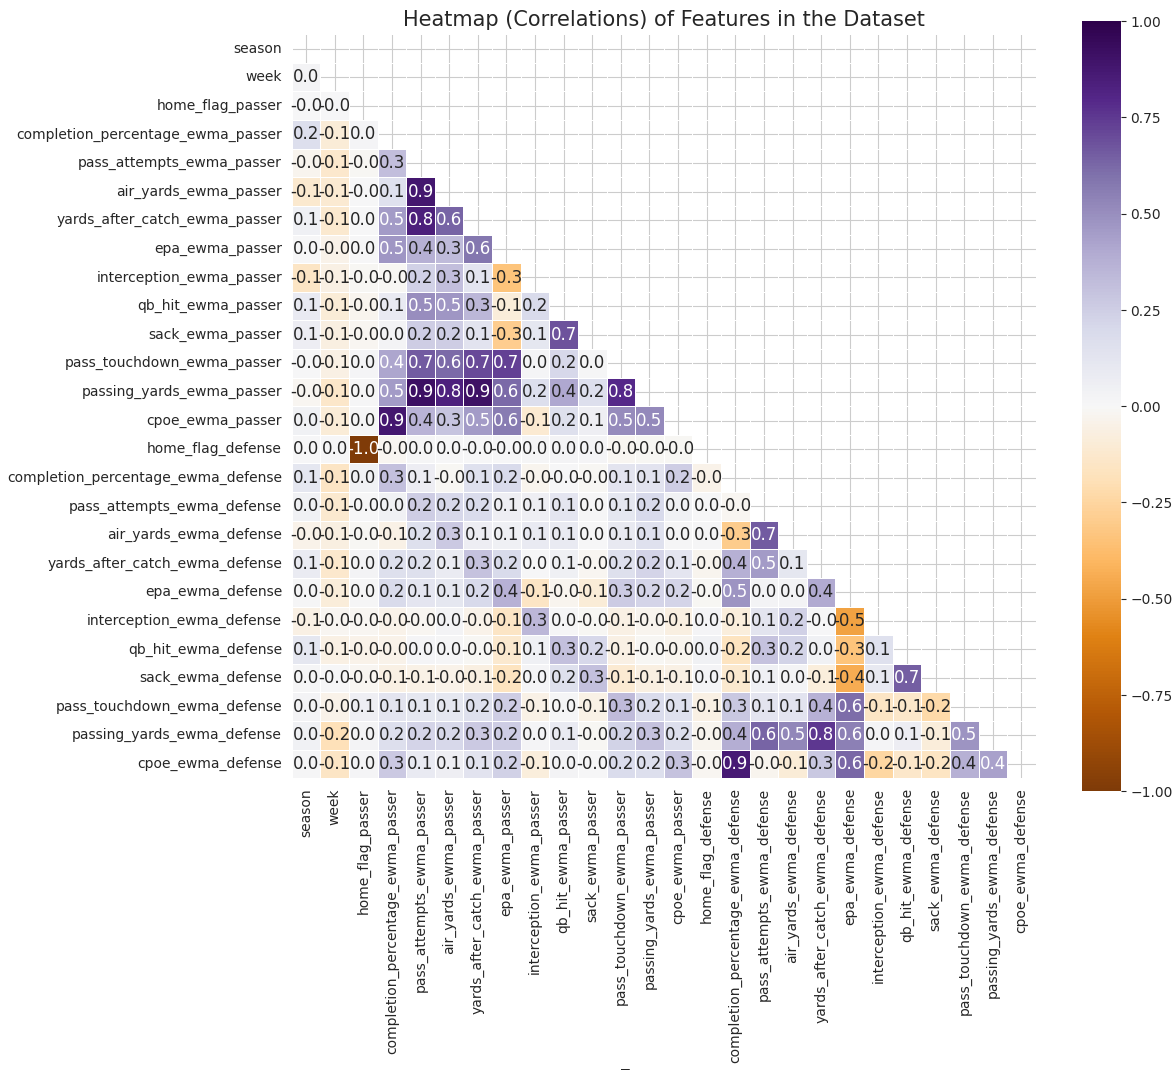

In [40]:
# Create a correlation for the dataset.
dataset_corr = df.corr()

# Drop Agent_ID from correlation dataset.
dataset_corr = dataset_corr.drop(['passing_yards'], axis=1)
dataset_corr = dataset_corr.drop(['passing_yards'], axis=0)

# Create a correlation matrix. Only bottom left corner valued.
mask = np.zeros_like(dataset_corr.round(4))
mask[np.triu_indices_from(mask)] = True

# Generate the corrleation matrix (heatmap) using Seaborn.
with sns.axes_style("whitegrid"):
    f, ax = plt.subplots(figsize=(12, 10))
    ax = sns.heatmap(dataset_corr.round(2), mask=mask, vmax=1, center=0, vmin=-1, square=True,
                     cmap='PuOr', linewidths=.5, annot=True, annot_kws={"size": 12}, fmt='.1f')
    plt.title('Heatmap (Correlations) of Features in the Dataset', fontsize=15)
    plt.xlabel('Features', fontsize=15)
    plt.ylabel('Features', fontsize=15)
plt.show()

In [41]:
df.isnull().sum()
final_df = df.dropna()

In [42]:
len(final_df)

9132

In [43]:
final_df.dtypes

passer_player_name                     object
posteam                                object
defteam                                object
season                                  int64
week                                    int32
passing_yards                         float32
home_flag_passer                         bool
roof                                   object
surface                                object
completion_percentage_ewma_passer     float64
pass_attempts_ewma_passer             float64
air_yards_ewma_passer                 float64
yards_after_catch_ewma_passer         float64
epa_ewma_passer                       float64
interception_ewma_passer              float64
qb_hit_ewma_passer                    float64
sack_ewma_passer                      float64
pass_touchdown_ewma_passer            float64
passing_yards_ewma_passer             float64
cpoe_ewma_passer                      float64
home_flag_defense                        bool
completion_percentage_ewma_defense

In [44]:
# Identify categorical columns to be encoded
categorical_cols = ['passer_player_name', 'posteam', 'defteam', 'roof', 'surface']

# Perform one-hot encoding
final_df = pd.get_dummies(final_df, columns=categorical_cols, drop_first=True)


In [45]:
final_df.to_csv('model_trained_on_data.csv', index=False)

In [19]:
# Define your features (X) and target (y)
X = final_df.drop(['passing_yards','week','season'], axis=1)  # Features
y = final_df['passing_yards']              # Target

# Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Instantiate the models
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'LightGBM': LGBMRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR(),
}

# Regression models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate metrics
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = {'RMSE': rmse, 'R-squared': r2, 'MAE': mae}

# Print the comparison results
results_df = pd.DataFrame(results).T.sort_values(by='RMSE')
print(results_df)

# You would choose the best model based on the lowest RMSE
best_model_name = results_df.index[0]
best_model = models[best_model_name]
print(f"\nThe best performing model is: {best_model_name}")

c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001377 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5952
[LightGBM] [Info] Number of data points in the train set: 7305, number of used features: 193
[LightGBM] [Info] Start training from score 219.947159


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


                   RMSE  R-squared        MAE
RandomForest  64.663828   0.548810  50.334018
LightGBM      64.797918   0.546936  50.744637
XGBoost       66.850899   0.517773  51.723770
SVR           67.904254   0.502457  53.274268

The best performing model is: RandomForest


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [21]:
# Fine-tuning LightGBM (assuming it was the best model)
lgbm = LGBMRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70],
    'reg_alpha': [0, 0.1, 0.5]
}

# Perform Grid Search with cross-validation
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid,
                           cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)

grid_search.fit(X_train, y_train)

# Get the best model and its parameters
tuned_lgbm = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"\nBest parameters found: {grid_search.best_params_}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5952
[LightGBM] [Info] Number of data points in the train set: 7305, number of used features: 193
[LightGBM] [Info] Start training from score 219.947159

Best parameters found: {'learning_rate': 0.05, 'n_estimators': 100, 'num_leaves': 31, 'reg_alpha': 0.5}


In [22]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Instantiate the RandomForest model
rf = RandomForestRegressor(random_state=42)

# Perform Grid Search with cross-validation
grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid,
                              cv=5, scoring='neg_root_mean_squared_error',
                              n_jobs=-1, verbose=1)

grid_search_rf.fit(X_train, y_train)

# Get the best model and its parameters
tuned_rf = grid_search_rf.best_estimator_
rf_best_params = grid_search_rf.best_params_
print(f"Best parameters found for RandomForest: {grid_search_rf.best_params_}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
405 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\skle

Best parameters found for RandomForest: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


In [23]:
from sklearn.metrics import mean_absolute_error

lgbm_tuned_model = LGBMRegressor(**best_params, random_state=42)

lgbm_tuned_model.fit(X_train, y_train)
y_pred = lgbm_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001482 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5952
[LightGBM] [Info] Number of data points in the train set: 7305, number of used features: 193
[LightGBM] [Info] Start training from score 219.947159
R2 Score: 0.5554792030654834
RMSE: 64.18411137681629
MAE: 50.2606486274943


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [24]:
from sklearn.metrics import mean_absolute_error

rf_tuned_model = RandomForestRegressor(**rf_best_params, random_state=42)

rf_tuned_model.fit(X_train, y_train)
y_pred = rf_tuned_model.predict(X_test)

# Calculate metrics
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R2 Score: {r2}')
print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

R2 Score: 0.5473453639741849
RMSE: 64.76866969546805
MAE: 50.87981299011506


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [21]:
from sklearn.linear_model import LinearRegression
# Define the meta-model
meta_model = LinearRegression()

# Train the base models on the training data
lgbm_tuned_model.fit(X_train, y_train)
rf_tuned_model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5970
[LightGBM] [Info] Number of data points in the train set: 6385, number of used features: 185
[LightGBM] [Info] Start training from score 210.024589


RandomForestRegressor(max_features='sqrt', min_samples_split=5,
                      n_estimators=300, random_state=42)

In [22]:
lgbm_preds = lgbm_tuned_model.predict(X_test)
rf_preds = rf_tuned_model.predict(X_test)

# Combine the predictions into a new DataFrame to serve as the meta-model's features
stacked_features = pd.DataFrame({
    'LGBM_preds': lgbm_preds,
    'RF_preds': rf_preds
})

# Train the meta-model on the base models' predictions
meta_model.fit(stacked_features, y_test)

# Make final predictions with the stacked ensemble
final_predictions = meta_model.predict(stacked_features)

# Evaluate the final ensemble model
mae = mean_absolute_error(y_test, final_predictions)
rmse = mean_squared_error(y_test, final_predictions, squared=False)

print(f"Ensemble Mean Absolute Error (MAE): {mae}")
print(f"Ensemble Root Mean Squared Error (RMSE): {rmse}")

Ensemble Mean Absolute Error (MAE): 52.101195448326045
Ensemble Root Mean Squared Error (RMSE): 66.53006576376436


c:\Users\rfo7799\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [26]:
X_train.columns

Index(['season', 'week', 'home_flag_passer',
       'completion_percentage_ewma_passer', 'pass_attempts_ewma_passer',
       'air_yards_ewma_passer', 'yards_after_catch_ewma_passer',
       'epa_ewma_passer', 'interception_ewma_passer', 'qb_hit_ewma_passer',
       ...
       'roof_dome', 'roof_open', 'roof_outdoors', 'surface_astroplay',
       'surface_astroturf', 'surface_dessograss', 'surface_fieldturf',
       'surface_grass', 'surface_matrixturf', 'surface_sportturf'],
      dtype='object', length=278)

In [30]:
import joblib
# Save the tuned LGBM model for rushing yards
joblib.dump(rf_tuned_model, 'rf_passing_model.joblib')

# Save the tuned Random Forest model for rushing yards
joblib.dump(lgbm_tuned_model, 'rf_rushing_model.joblib')

print("All optimal models have been saved to disk.")

All optimal models have been saved to disk.
